In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import os
import pandas as pd

from robin.kernel.entities import Kernel

In [3]:
path_config_supply = '../data/MAD-BCN/supply_MAD-BCN_2025.yaml'
path_config_demand = '../data/MAD-BCN/demand_data.yaml'
path_kernel_output = '../data/MAD-BCN/kernel_output'
kernel_output_file = 'output.csv'

path_prices_data = '../data/MAD-BCN/prices/prices_MAD-BCN_2025.csv'
figures_path = '../figures/MAD-BCN'

os.makedirs(path_kernel_output, exist_ok=True)
os.makedirs(figures_path, exist_ok=True)

# Set the random seed for reproducibility
seed = 2025


In [4]:
kernel = Kernel(path_config_supply, path_config_demand, seed)
services = kernel.simulate(os.path.join(path_kernel_output, kernel_output_file),
                            departure_time_hard_restriction=False,
                            calculate_global_utility=False)


In [5]:
# Merge the kernel output with the name of the selected service
kernel_output = pd.read_csv(os.path.join(path_kernel_output, kernel_output_file))
prices_data = pd.read_csv(path_prices_data)
kernel_output = kernel_output.merge(prices_data[['service_id', 'train_type']], left_on='service', right_on='service_id', how='left')

# Save the merged data to a new CSV file
output_file = os.path.join(path_kernel_output, 'output_with_service.csv')
kernel_output.to_csv(output_file, index=False)

# Display the first few rows of the merged DataFrame
kernel_output.head(5)

,id,user_pattern,departure_station,arrival_station,arrival_day,arrival_time,purchase_date,service,service_departure_time,service_arrival_time,seat,price,utility,best_service,best_seat,best_utility,service_id,train_type
0,10788,Leisure,60000,71801,2025-01-01,13.841214,2024-12-06,00009_01-01-2025-12.22,12.366667,15.233333,BasicSeat,29.04,8.801841,00009_01-01-2025-12.22,BasicSeat,8.801841,00009_01-01-2025-12.22,IRYO
1,10660,Leisure,60000,71801,2025-01-01,8.487919,2024-12-08,00009_01-01-2025-17.22,17.366667,20.233333,BasicSeat,25.63,8.741205,00009_01-01-2025-17.22,BasicSeat,8.741205,00009_01-01-2025-17.22,IRYO
2,9333,Leisure,60000,71801,2025-01-01,12.059012,2024-12-09,00019_01-01-2025-19.34,19.566667,22.916667,BasicSeat,32.14,8.868130,00019_01-01-2025-19.34,BasicSeat,8.868130,00019_01-01-2025-19.34,AVLO
3,10725,Leisure,60000,71801,2025-01-01,14.041513,2024-12-09,00018_01-01-2025-15.27,15.450000,18.766667,BasicSeat,29.46,8.613906,00018_01-01-2025-15.27,BasicSeat,8.613906,00018_01-01-2025-15.27,AVLO
4,11646,Leisure,60000,71801,2025-01-01,14.190313,2024-12-09,00006_01-01-2025-07.27,7.450000,10.766667,BasicSeat,27.76,8.151557,00006_01-01-2025-07.27,BasicSeat,8.151557,00006_01-01-2025-07.27,AVE


## Plot some visualizations of the data synthetic data generated

train_type
AVE        1518363
IRYO       1397268
OUIGO       713534
AVLO        623624
AVE INT      28317
Name: count, dtype: int64


/var/folders/n5/s8_w_cgn3jd6kv8h7psy1jnr0000gn/T/ipykernel_7319/127827151.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=tickets_per_train.index, y=tickets_per_train.values, palette=colors)


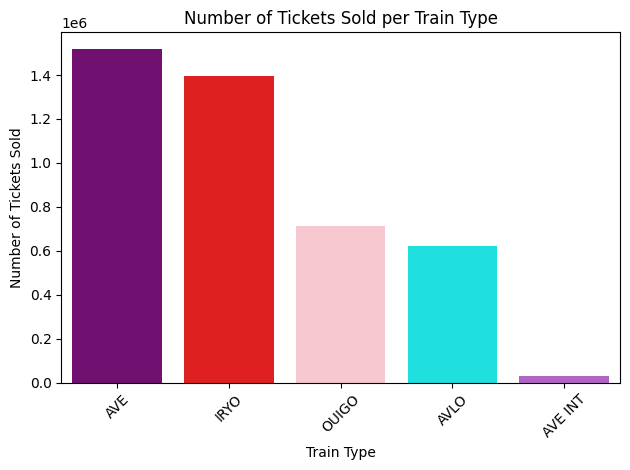

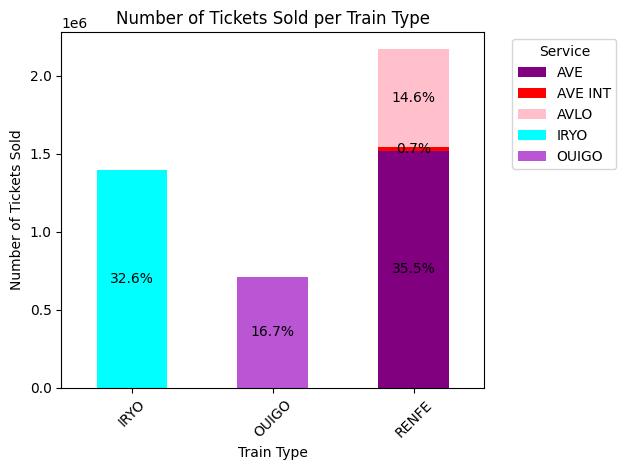

In [9]:

# Show a summary of the number of tickets sold for train_type
tickets_per_train = kernel_output['train_type'].value_counts()

# Definir mapa de colores para cada servicio
color_map = {
    'AVE': 'purple',
    'AVE INT': '#BA55D3',  # Medium Orchid
    'AVLO': 'aqua',
    'OUIGO': 'pink',
    'IRYO': 'red'
}
# Para cualquier otro servicio que aparezca, se usará 'grey'
colors = [color_map.get(s, 'grey') for s in tickets_per_train.index]


# Display the summary
print(tickets_per_train)
# Plot the number of tickets sold for each train type
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure()
sns.barplot(x=tickets_per_train.index, y=tickets_per_train.values, palette=colors)
plt.title('Number of Tickets Sold per Train Type')
plt.xlabel('Train Type')
plt.ylabel('Number of Tickets Sold')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()





kernel_output['train_type_agg'] = kernel_output.apply(
    lambda row: 'RENFE' if row['train_type'] in ['AVLO', 'AVE', 'AVE INT'] else row['train_type'],
    axis=1
)

# Calcular tickets_per_train apilado por servicio
tickets_per_train = (
    kernel_output
    .groupby(['train_type_agg', 'train_type'])
    .size()
    .unstack(fill_value=0)
)

# Dibujar la barra apilada con colores personalizados
plt.figure()
tickets_per_train.plot(
    kind='bar',
    stacked=True,
    color=colors,
    ax=plt.gca()
)

# Dibujar en medio de cada gráfica el porcentaje de cada servicio 
total = tickets_per_train.sum().sum()
for i, (train_type, row) in enumerate(tickets_per_train.iterrows()):
    #total = row.sum()
    for j, (service, count) in enumerate(row.items()):
        if count > 0:
            percentage = count / total * 100
            plt.text(i, row[:j + 1].sum() - count / 2, f'{percentage:.1f}%', ha='center', va='center', color='black')

plt.title('Number of Tickets Sold per Train Type')
plt.xlabel('Train Type')
plt.ylabel('Number of Tickets Sold')
plt.xticks(rotation=45)
plt.legend(title='Service', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.savefig(os.path.join(figures_path, 'tickets_per_train_type.png'), bbox_inches='tight')
plt.show()

<u>**Real demand of the MAD – BCN corridor in 2024**</u>

**Total demand:** **8 690 000** passengers

| Service | Passengers  | % of total |
|:--------|------------:|-----------:|
| Renfe   |   4 051 719 |      46.6% |
| Ouigo   |   1 616 947 |      18.6% |
| Iryo    |   3 008 843 |      34.6% |


Demand by train type:

| Train type    | % of total |
|:--------------|-----------:|
| AVE + AVE INT |      36.3% |
| AVLO          |      10.3% |
| Ouigo         |      18.6% |
| Iryo          |      34.8% |

* Data obtained from the annual report on the railway sector by the Comisión Nacional de los Mercados y la Competencia (CNMC).

* The demand simulated in this notebook is based on the real demand of the MAD-BCN corridor in 2024, as reported by the CNMC.
However, the demand is divided by two to account only for the demand of the corridor in the direction MAD-BCN, as the demand in the opposite direction is not considered in this simulation.

In [10]:
from robin.plotter.entities import KernelPlotter

kernel_plotter = KernelPlotter(
    path_output_csv=os.path.join(path_kernel_output, kernel_output_file),
    path_config_supply=path_config_supply,
)

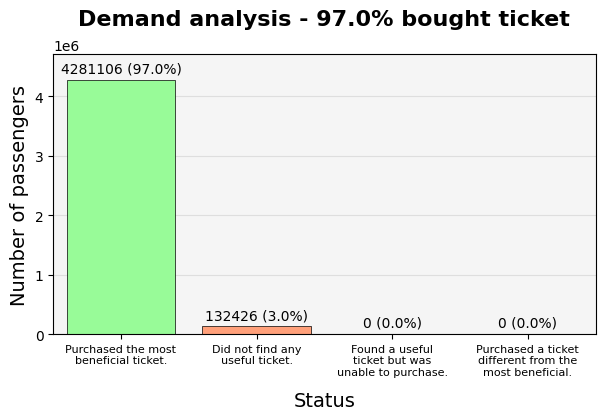

In [11]:
# Plot an analysis of the demand
kernel_plotter.plot_demand_status(save_path=f'{figures_path}/demand_status.pdf')

In [12]:
# Plot the distribution of all the seat types
#kernel_plotter.plot_seat_distribution_pie_chart(save_path=f'{figures_path}/pie.pdf')

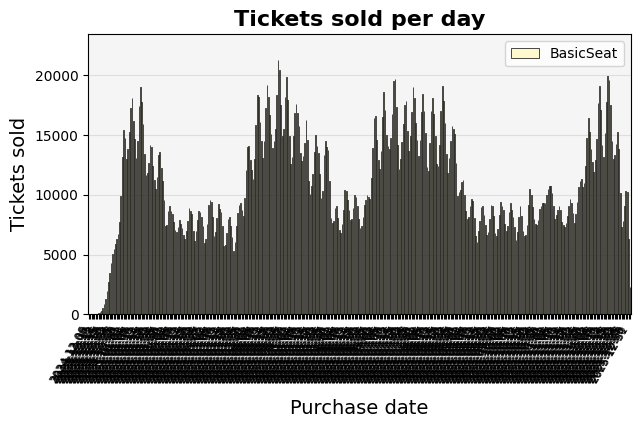

In [13]:
# Plot the distribution of the tickets sold by date
kernel_plotter.plot_tickets_by_date(save_path=f'{figures_path}/total_tickets_sold.pdf')

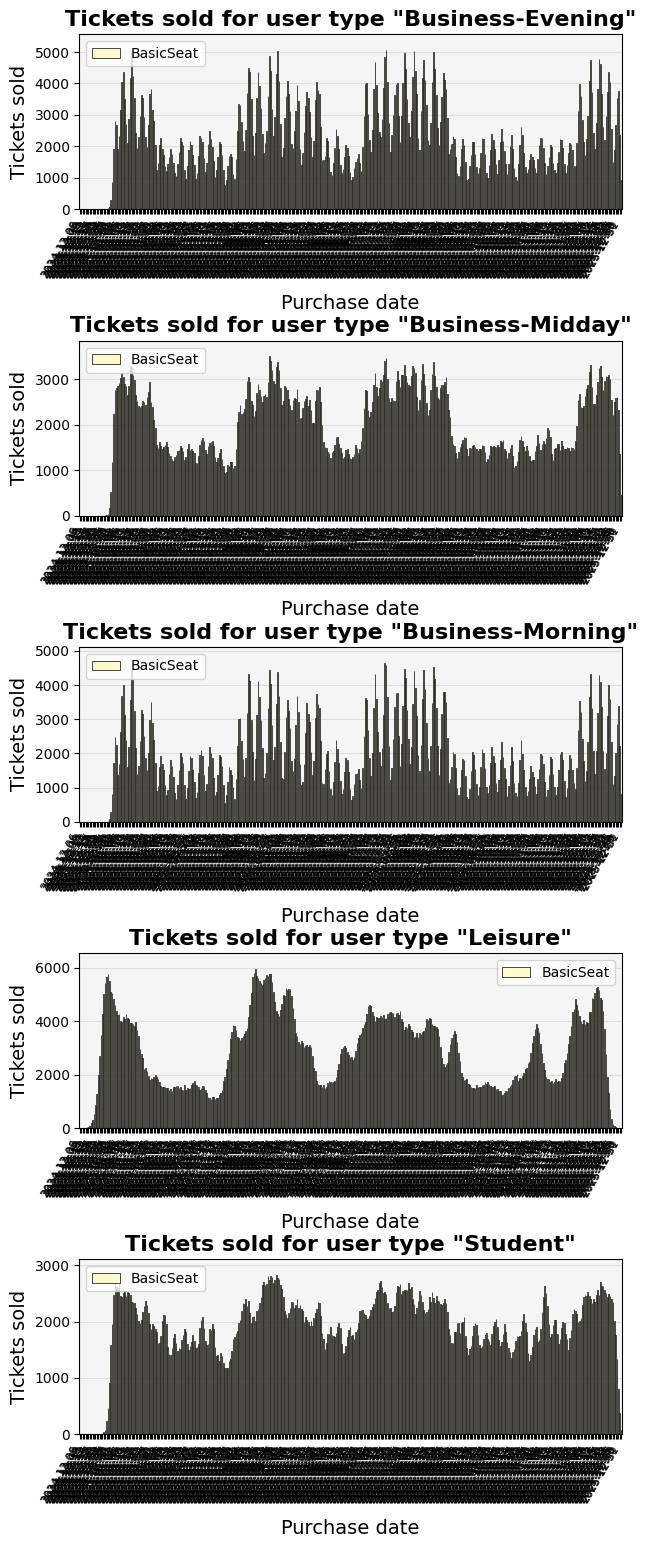

In [14]:
kernel_plotter.plot_tickets_by_user()